In [485]:
import pandas as pd
import xgboost as xgb
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [486]:
df = pd.read_csv('../data/transformed_data.csv')
df.head()

,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,lon_sin,lon_cos,lat_sin,lat_cos
0,547.033,5.5000,63.0,39.0,5.976,1.13,8.66,7.704,-0.001773,-0.999998,-0.397680,0.917524
1,11.854,5.5000,58.0,53.0,1.485,1.40,5.21,4.721,0.798010,-0.602644,0.126827,0.991925
2,35.000,6.4000,118.0,30.0,1.178,1.17,7.94,1.842,0.801545,-0.597934,0.128626,0.991693
3,62.384,5.0000,47.0,79.0,2.388,0.54,9.64,6.266,0.203702,-0.979033,-0.302829,0.953045
4,NaN,5.3678,112.0,54.0,1.991,0.88,6.54,1.848,0.964159,0.265326,0.605326,0.795978


In [487]:
strategy = 'median'
imputer = SimpleImputer(strategy=strategy)
scaler = StandardScaler()

In [488]:
X = df.drop(["mag"], axis=1)
y = df["mag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [489]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed), 
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed), 
    columns=X_test.columns
)

# Model prédiction

In [490]:
def search_hyperparameters(X_train, y_train, n_iter=50, n_splits=5):
    param_distributions = {
        'max_depth':        [3, 4, 5, 6, 7, 8, 9],
        'min_child_weight': [1, 3, 5, 7, 10],
        'n_estimators':     [100, 200, 300, 500, 700, 1000],
        'learning_rate':    [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
        'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'gamma':            [0, 0.1, 0.2, 0.3, 0.5],
    }

    search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42),
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=TimeSeriesSplit(n_splits=n_splits),
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

    search.fit(X_train, y_train)

    print(f"Meilleurs hyperparamètres : {search.best_params_}")
    print(f"Meilleur RMSE CV         : {-search.best_score_:.4f}")

    return search.best_estimator_

In [491]:
xgb_model = search_hyperparameters(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs hyperparamètres : {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Meilleur RMSE CV         : 0.3466


## Analyse


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

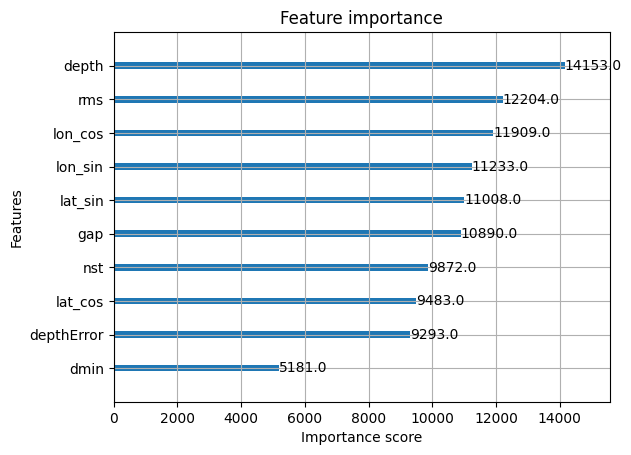

In [492]:
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

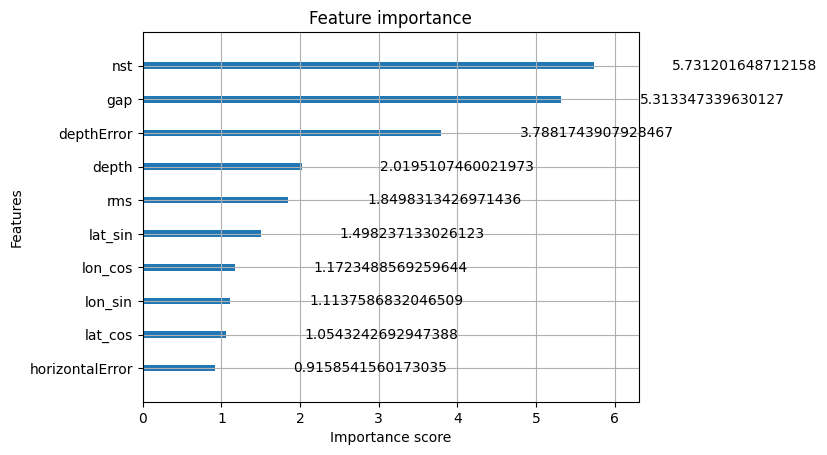

In [493]:
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=10)

In [494]:
y_pred = xgb_model.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {rmse_base}")
print(f"R²   : {r2_score(y_test, y_pred)}")

MAE  : 0.5714439494787383
RMSE : 0.7490116873134804
R²   : -0.9452477535157549


In [495]:
joblib.dump(xgb_model, '../data/xgb_model.pkl')
joblib.dump(imputer,   '../data/imputer.pkl')
joblib.dump(scaler,    '../data/scaler.pkl')

['../data/scaler.pkl']

# Tests

## Tests d'isolement

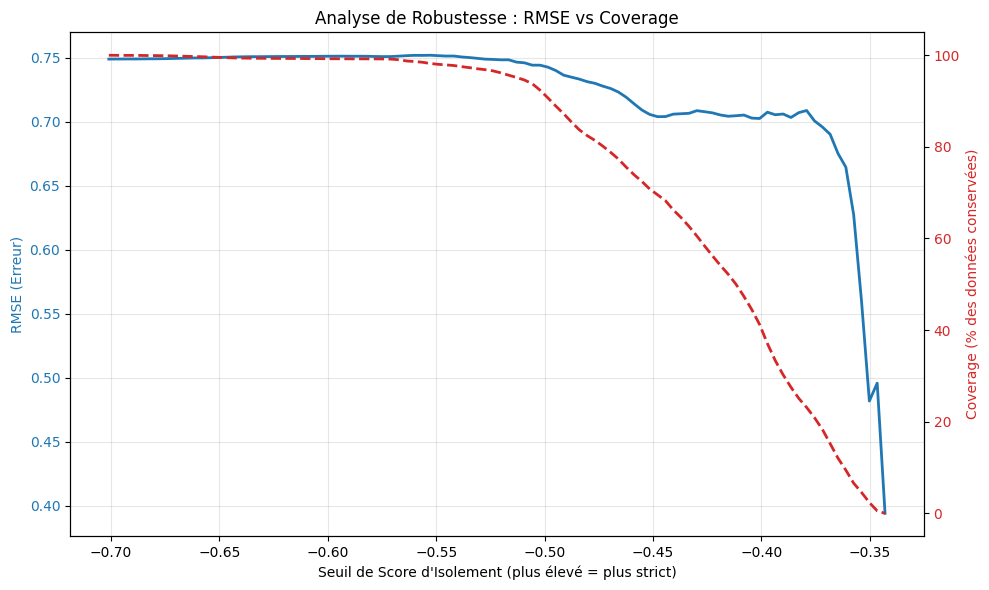

In [496]:
iso_forest = IsolationForest(random_state=42)
iso_forest.fit(X_train_scaled)

anomaly_scores = iso_forest.score_samples(X_test_scaled)

thresholds = np.linspace(anomaly_scores.min(), anomaly_scores.max(), 100)
count, rmse = [], []
n_total = len(y_test)

for t in thresholds:
    mask = anomaly_scores >= t
    count.append(100 *mask.sum()/n_total)
    error = mean_squared_error(y_test[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    rmse.append(np.sqrt(error))

fig, ax1 = plt.subplots(figsize=(10, 6))

# ax1 : RMSE
ax1.plot(thresholds, rmse, color='tab:blue', linewidth=2, label='RMSE')
ax1.set_xlabel('Seuil de Score d\'Isolement (plus élevé = plus strict)')
ax1.set_ylabel('RMSE (Erreur)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# ax2 : Coverage
ax2 = ax1.twinx()
ax2.plot(thresholds, count, color='tab:red', linestyle='--', linewidth=2, label='Coverage %')
ax2.set_ylabel('Coverage (% des données conservées)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Titre et légende
plt.title('Analyse de Robustesse : RMSE vs Coverage')
fig.tight_layout()

Un threshold à -0.45 nous parait cohérent, nous gardons 70% de la donnée avec une RSME qui ne chute pas de beaucoup.

Comme le montre les graphs de l'exploration du dataset, le fait que nous avons de plus en plus de données au cours des années et des données de plus en plus précises, la variance réduit. Ce faisant notre model conserve une RMSE correcte jusqu'à 10% de coverage car les données récentes ont très peu de variance et les anciennes très peu de présence, donc filtrer 90% des données revient à retirer des points quasi-identiques aux restants.

Ici nous avons laissé les données antérieures aux années 2000, mais si nous les enlevons la RSME reste très stable autour de 0.32 malgré un coverage qui descend. Nous avons décidé de garder les données antérieures pour avoir un graph plus proche de la silhouette désirée comme dans le cours, mais nos scores s'améliorent si nous les retirons.

## Tests d'imputation

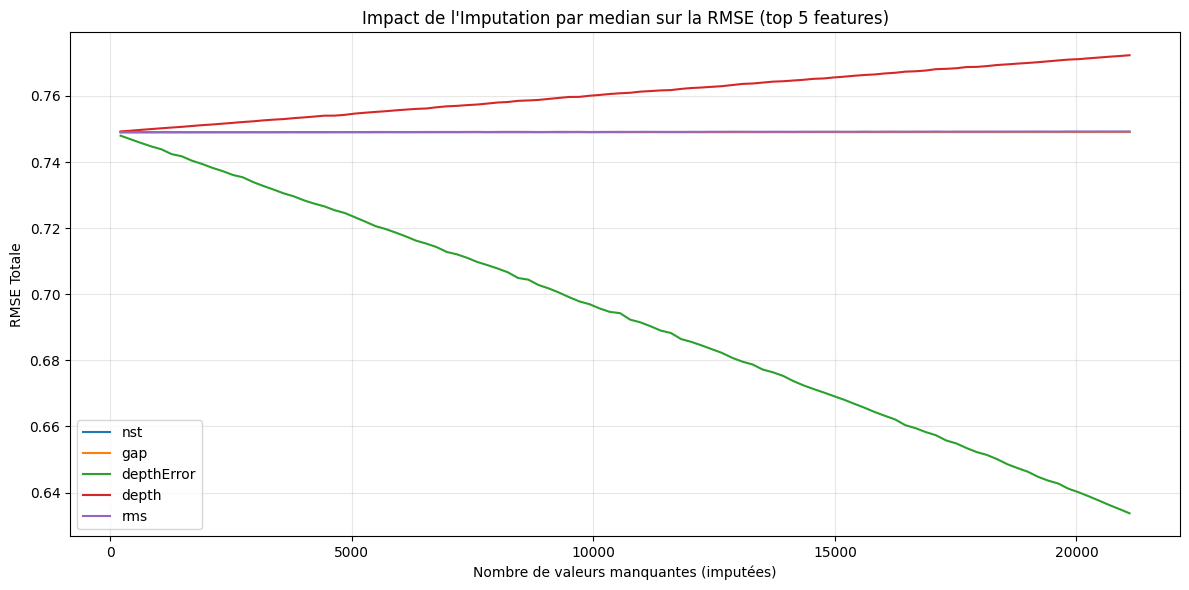

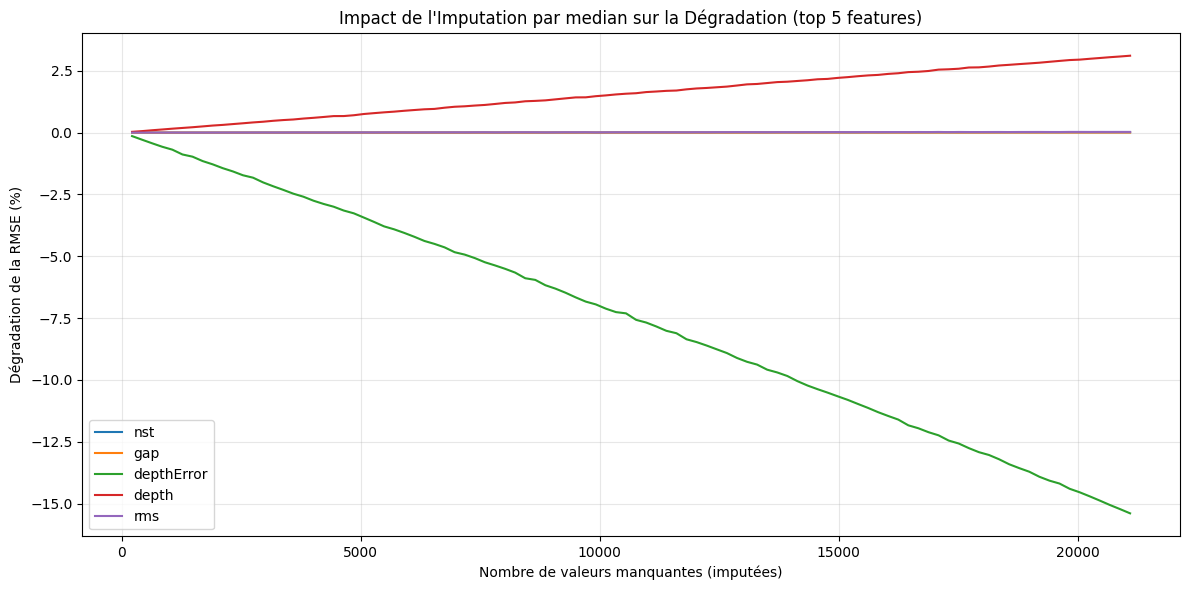

In [497]:
top5_features = (
    pd.Series(xgb_model.feature_importances_, index=X_train_scaled.columns)
    .nlargest(5)
    .index.tolist()
)
feature_indices = [X.columns.get_loc(f) for f in top5_features]

range_scale = int(X_test.shape[0] / 100)
n_missing_range = range(range_scale, X_test.shape[0], range_scale)

rmse_by_feature = {}
degradation_by_feature = {}

for feature_idx in feature_indices:
    rmse_imputation = []
    degradation = []

    for n_missing in n_missing_range:
        rmse_val = []

        for i in range(5):
            X_test_corrupted = X_test.copy()
            random_indices = np.random.choice(X_test_corrupted.shape[0], n_missing, replace=False)
            X_test_corrupted.iloc[random_indices, feature_idx] = np.nan

            X_test_imputed = imputer.transform(X_test_corrupted)
            X_test_imputed = scaler.transform(X_test_imputed)

            y_pred_imputed = xgb_model.predict(X_test_imputed)
            rmse_val.append(np.sqrt(mean_squared_error(y_test, y_pred_imputed)))

        rmse_imputation.append(np.mean(rmse_val))
        degradation.append((np.mean(rmse_val) - rmse_base) / rmse_base * 100)

    rmse_by_feature[X.columns[feature_idx]] = rmse_imputation
    degradation_by_feature[X.columns[feature_idx]] = degradation

plt.figure(figsize=(12, 6))
for feature_name, rmse_vals in rmse_by_feature.items():
    plt.plot(n_missing_range, rmse_vals, linestyle='-', label=feature_name)
plt.xlabel('Nombre de valeurs manquantes (imputées)')
plt.ylabel('RMSE Totale')
plt.title(f'Impact de l\'Imputation par {strategy} sur la RMSE (top 5 features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(12, 6))
for feature_name, deg_vals in degradation_by_feature.items():
    plt.plot(n_missing_range, deg_vals, linestyle='-', label=feature_name)
plt.xlabel('Nombre de valeurs manquantes (imputées)')
plt.ylabel('Dégradation de la RMSE (%)')
plt.title(f'Impact de l\'Imputation par {strategy} sur la Dégradation (top 5 features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

L'explication sur la distribution de notre dataset est d'autant plus flagrante ici. En remplacant par la médiane (grandement influencée par les données recentes) la RSME diminue, car nous corrigons les incertitudes des mesures des 19 et 20e siècles.

Encore une fois, si nous enlevons les données antérieures aux années 2000, nous avons une imputation par la médiane qui augmente notre RSME car nous perdons en précision. En revanche, même en remplacant toutes les variables de la feature la plus importante par sa médiane, nous n'augmentons la RMSE que de 40% car les données récentes sont très peu volatiles, très rapprochées dans l'espace.

## Tests de bruit

In [498]:
def noise_importance(
        model,
        X_test,
        y_test,
        noise_levels,
        n_repeats=10,
        random_state=42
):
    rng = np.random.default_rng(random_state)
    n_features = X_test.shape[1]

    rmse_clean = np.sqrt(mean_squared_error(y_test, y_pred))

    results = np.zeros((n_features, len(noise_levels)))

    for j in range(n_features):
        for k, level in enumerate(noise_levels):
            rmse_runs = []

            for _ in range(n_repeats):
                X_noisy = X_test.copy()
                noise = rng.normal(
                    0,
                    level / 100,
                    size=X_test.shape[0]
                )
                X_noisy[:, j] += noise

                preds = model.predict(X_noisy)
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmse_runs.append(rmse)

            results[j, k] = 100 * (np.mean(rmse_runs) - rmse_clean) / rmse_clean

    return results

In [499]:
noise_levels = np.array([1, 3, 5, 10, 15, 20])

# importance_matrix = noise_importance(
#     xgb_model,
#     X_test.to_numpy(),
#     y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test,
#     noise_levels,
#     n_repeats=20
# )